<a href="https://colab.research.google.com/github/Thalapathi26/AI_ML/blob/main/boosting_practce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [ ]:
df=pd.read_csv('/content/airline_financial_impact.csv')
df.head()

,quarter,month,conflict_phase,airline,country,region,airline_type,fleet_size,revenue_usd_m,fuel_cost_usd_m,fuel_cost_pct_revenue,net_profit_usd_m,profit_margin_pct,passengers_carried_m,fuel_hedging_pct,hedge_savings_usd_m,brent_crude_usd_barrel,jet_fuel_usd_barrel,daily_fuel_consumption_bbl,quarterly_fuel_bbl
0,2019-Q1,2019-01,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,260,7254.03,576.88,7.95,995.04,13.72,2.31,64.0,0.0,63.00,74.58,85000,7735000
1,2019-Q2,2019-04,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,260,7685.08,567.28,7.38,973.28,12.66,2.86,56.0,0.0,64.79,73.34,85000,7735000
2,2019-Q3,2019-07,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,260,7655.78,550.04,7.18,994.88,13.00,2.64,61.1,0.0,60.46,71.11,85000,7735000
3,2019-Q4,2019-10,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,260,7250.33,595.36,8.21,818.21,11.29,2.63,53.4,0.0,65.66,76.97,85000,7735000
4,2020-Q1,2020-01,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,260,7583.43,583.06,7.69,330.17,4.35,2.76,1.5,0.0,66.66,75.38,85000,7735000


In [ ]:
df.isnull().sum()

,0
quarter,0
month,0
conflict_phase,0
airline,0
country,0
region,0
airline_type,0
fleet_size,0
revenue_usd_m,0
fuel_cost_usd_m,0


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
for i in df.columns:
  if df[i].dtype=='int64' or df[i].dtype=='float64':
    df[i]=sc.fit_transform(df[[i]])
df

,quarter,month,conflict_phase,airline,country,region,airline_type,fleet_size,revenue_usd_m,fuel_cost_usd_m,fuel_cost_pct_revenue,net_profit_usd_m,profit_margin_pct,passengers_carried_m,fuel_hedging_pct,hedge_savings_usd_m,brent_crude_usd_barrel,jet_fuel_usd_barrel,daily_fuel_consumption_bbl,quarterly_fuel_bbl
0,2019-Q1,2019-01,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,-0.146068,0.942620,0.479498,-0.822256,1.620196,0.841915,-0.063320,1.868714,-0.397431,-0.755772,-0.697768,0.966471,0.966471
1,2019-Q2,2019-04,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,-0.146068,1.050793,0.450676,-0.857932,1.577184,0.777374,0.138139,1.418152,-0.397431,-0.670835,-0.748066,0.966471,0.966471
2,2019-Q3,2019-07,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,-0.146068,1.043440,0.398915,-0.870450,1.619880,0.798076,0.057555,1.705385,-0.397431,-0.876296,-0.838521,0.966471,0.966471
3,2019-Q4,2019-10,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,-0.146068,0.941692,0.534982,-0.805983,1.270664,0.693959,0.053892,1.271719,-0.397431,-0.629554,-0.600822,0.966471,0.966471
4,2020-Q1,2020-01,Pre-Pandemic Baseline,Emirates,UAE,Middle East,Flag Carrier,-0.146068,1.025284,0.498053,-0.838529,0.305977,0.271401,0.101510,-1.651302,-0.397431,-0.582103,-0.665317,0.966471,0.966471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720,2025-Q1,2025-01,Pre-Iran Escalation,EgyptAir,Egypt,Africa,Flag Carrier,-0.751909,-0.768173,-0.919611,0.268685,-0.251953,0.674475,-0.634730,0.995750,-0.263140,0.294308,0.395811,-1.046321,-1.046321
721,2025-Q2,2025-04,Pre-Iran Escalation,EgyptAir,Egypt,Africa,Flag Carrier,-0.751909,-0.760916,-0.857672,0.447692,-0.289293,0.385869,-0.623741,-1.088100,-0.297978,1.083884,1.162046,-1.046321,-1.046321
722,2025-Q3,2025-07,Pre-Iran Escalation,EgyptAir,Egypt,Africa,Flag Carrier,-0.751909,-0.766790,-0.884603,0.413893,-0.225387,0.851048,-0.623741,1.130919,-0.097708,0.679131,0.829024,-1.046321,-1.046321
723,2025-Q4,2025-10,Pre-Iran Escalation,EgyptAir,Egypt,Africa,Flag Carrier,-0.751909,-0.770070,-0.886404,0.458332,-0.280299,0.482680,-0.642055,-1.189476,-0.341963,0.968579,0.806714,-1.046321,-1.046321


In [ ]:
from sklearn.preprocessing import LabelEncoder
lr=LabelEncoder()
for i in df.columns:
  if df[i].dtype=='object':
    df[i]=lr.fit_transform(df[[i]])
df

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

,quarter,month,conflict_phase,airline,country,region,airline_type,fleet_size,revenue_usd_m,fuel_cost_usd_m,fuel_cost_pct_revenue,net_profit_usd_m,profit_margin_pct,passengers_carried_m,fuel_hedging_pct,hedge_savings_usd_m,brent_crude_usd_barrel,jet_fuel_usd_barrel,daily_fuel_consumption_bbl,quarterly_fuel_bbl
0,0,0,3,8,16,3,0,-0.146068,0.942620,0.479498,-0.822256,1.620196,0.841915,-0.063320,1.868714,-0.397431,-0.755772,-0.697768,0.966471,0.966471
1,1,1,3,8,16,3,0,-0.146068,1.050793,0.450676,-0.857932,1.577184,0.777374,0.138139,1.418152,-0.397431,-0.670835,-0.748066,0.966471,0.966471
2,2,2,3,8,16,3,0,-0.146068,1.043440,0.398915,-0.870450,1.619880,0.798076,0.057555,1.705385,-0.397431,-0.876296,-0.838521,0.966471,0.966471
3,3,3,3,8,16,3,0,-0.146068,0.941692,0.534982,-0.805983,1.270664,0.693959,0.053892,1.271719,-0.397431,-0.629554,-0.600822,0.966471,0.966471
4,4,4,3,8,16,3,0,-0.146068,1.025284,0.498053,-0.838529,0.305977,0.271401,0.101510,-1.651302,-0.397431,-0.582103,-0.665317,0.966471,0.966471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720,24,24,2,7,1,0,0,-0.751909,-0.768173,-0.919611,0.268685,-0.251953,0.674475,-0.634730,0.995750,-0.263140,0.294308,0.395811,-1.046321,-1.046321
721,25,25,2,7,1,0,0,-0.751909,-0.760916,-0.857672,0.447692,-0.289293,0.385869,-0.623741,-1.088100,-0.297978,1.083884,1.162046,-1.046321,-1.046321
722,26,26,2,7,1,0,0,-0.751909,-0.766790,-0.884603,0.413893,-0.225387,0.851048,-0.623741,1.130919,-0.097708,0.679131,0.829024,-1.046321,-1.046321
723,27,27,2,7,1,0,0,-0.751909,-0.770070,-0.886404,0.458332,-0.280299,0.482680,-0.642055,-1.189476,-0.341963,0.968579,0.806714,-1.046321,-1.046321


In [ ]:
x=df.drop('revenue_usd_m',axis=1)
y=df['revenue_usd_m']


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

<Axes: ylabel='fleet_size'>

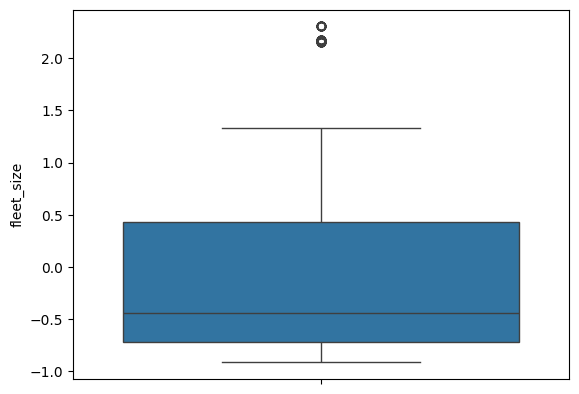

In [ ]:
sns.boxplot(df['fleet_size'])

In [ ]:
from scipy.stats import iqr

q1=df['fleet_size'].quantile(0.25)
q3=df['fleet_size'].quantile(0.75)
iqr=q3-q1

lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr

df['fleet_size']=np.where(df['fleet_size']<lower_bound,lower_bound,df['fleet_size'])
df['fleet_size']=np.where(df['fleet_size']>upper_bound,upper_bound,df['fleet_size'])



<Axes: ylabel='fleet_size'>

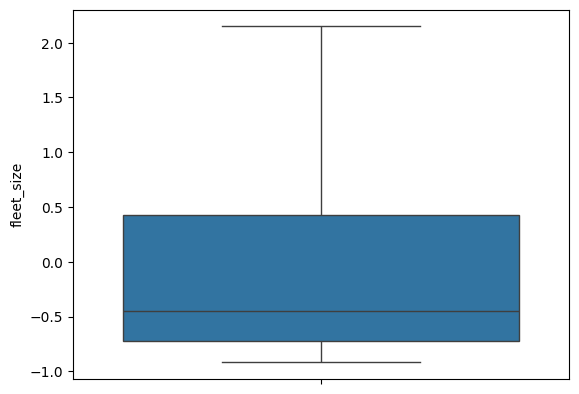

In [ ]:
sns.boxplot(df['fleet_size'])

<Axes: ylabel='revenue_usd_m'>

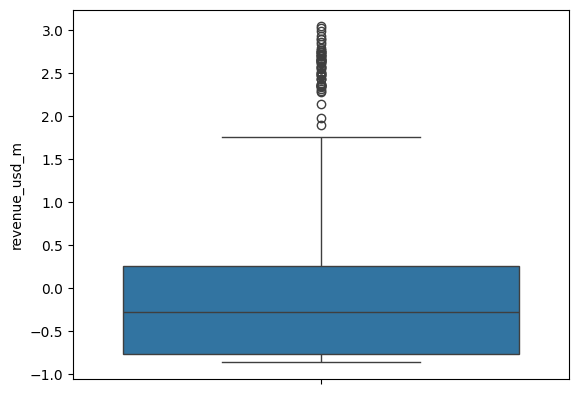

In [ ]:
sns.boxplot(df['revenue_usd_m'])

In [ ]:
q1=df['revenue_usd_m'].quantile(0.25)
q3=df['revenue_usd_m'].quantile(0.75)
iqr=q3-q1

lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr

df['revenue_usd_m']=np.where(df['revenue_usd_m']<lower_bound,lower_bound,df['revenue_usd_m'])
df['revenue_usd_m']=np.where(df['revenue_usd_m']>upper_bound,upper_bound,df['revenue_usd_m'])



<Axes: ylabel='revenue_usd_m'>

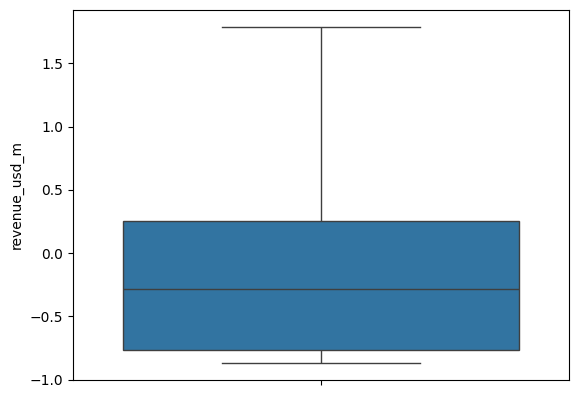

In [ ]:
sns.boxplot(df['revenue_usd_m'])

In [ ]:
sns.boxplot(df['fuel_cost_pct_revenue'])

In [ ]:
q1=df['fuel_cost_pct_revenue'].quantile(0.25)
q3=df['fuel_cost_pct_revenue'].quantile(0.75)
iqr=q3-q1

lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr

df['fuel_cost_pct_revenue']=np.where(df['fuel_cost_pct_revenue']<lower_bound,lower_bound,df['fuel_cost_pct_revenue'])
df['fuel_cost_pct_revenue']=np.where(df['fuel_cost_pct_revenue']>upper_bound,upper_bound,df['fuel_cost_pct_revenue'])


<Axes: ylabel='fuel_cost_pct_revenue'>

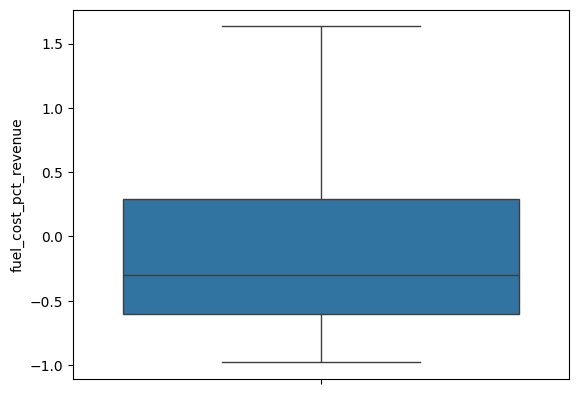

In [ ]:
sns.boxplot(df['fuel_cost_pct_revenue'])